In [46]:
import numpy as np
from figgie_gym.agent.cardcounter import ExpectedValueGeometricAggressive, PosteriorProbabilies, get_symbol_quantity_permutations
import pandas as pd

In [59]:
ev = ExpectedValueGeometricAggressive(400, 10, 4, 1.02, PosteriorProbabilies(get_symbol_quantity_permutations()))

<Axes: title={'center': 'Breakeven for Buying vs Selling a Card'}, xlabel='Inventory Quantity', ylabel='Breakeven buy/sell price'>

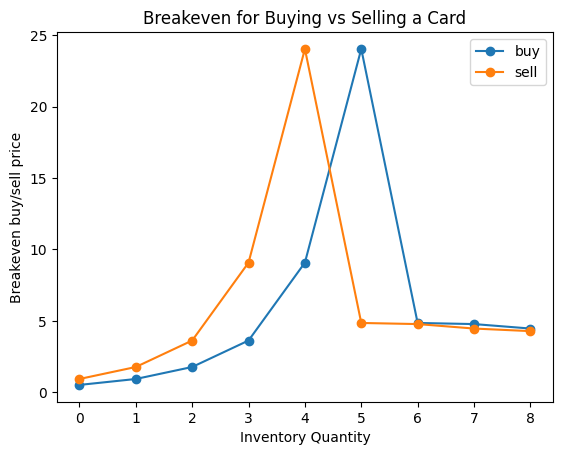

In [83]:
breakeven = [
    ev.compute_expected_value(
        # known_holdings = [min(i//2, 10), min(i//2, 10), max(2, i), min(i*2, 10)],
        known_holdings = [10, 2, max(2, i), min(i*2, 10)],
        current_holdings = [0, 0, i, 0]
    )[2] for i in range(0, 10)
]

breakeven = np.array(breakeven)
breakeven_buy = breakeven[:-1]
breakeven_sell = breakeven[1:]
pd.DataFrame({'buy': breakeven_buy, 'sell': breakeven_sell}).plot(marker='o', title='Breakeven for Buying vs Selling a Card', xlabel='Inventory Quantity', ylabel='Breakeven buy/sell price')

In [85]:
print(pd.DataFrame({'buy': breakeven_buy, 'sell': breakeven_sell}).round(4).to_markdown())

|    |     buy |    sell |
|---:|--------:|--------:|
|  0 |  0.5208 |  0.9362 |
|  1 |  0.9362 |  1.7754 |
|  2 |  1.7754 |  3.6281 |
|  3 |  3.6281 |  9.0789 |
|  4 |  9.0789 | 24.0344 |
|  5 | 24.0344 |  4.8571 |
|  6 |  4.8571 |  4.779  |
|  7 |  4.779  |  4.4665 |
|  8 |  4.4665 |  4.2857 |
